In [1]:
import warnings
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

In [2]:
import os
DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLS = ["CPI", "EXR"]
TEST_FRAC = 0.15
MIN_TEST = 4
P_RANGE = range(0, 3)
D_RANGE = range(0, 2)
Q_RANGE = range(0, 3)

# Residual-correction MLP: kept deliberately small — windows are short (as few
# as ~40 months) so a handful of residual lags is all the training data supports.
RESID_LAGS = 3
HIDDEN_DIM = 8
EPOCHS = 300
LR = 1e-2
WEIGHT_DECAY = 1e-3

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE").asfreq("MS")


df = load_data(DATA_PATH)[FEATURE_COLS]

# Same structural-break partition as every other notebook in this project, so all
# models are compared on identical windows. "W5" is the full, unsegmented series.
BREAK_DATES = pd.to_datetime(["2008-06-01", "2016-10-01", "2022-03-01"])
EDGES = [df.index.min(), *BREAK_DATES, df.index.max() + pd.DateOffset(days=1)]

WINDOWS = {f"W{i + 1}": (EDGES[i], EDGES[i + 1] - pd.DateOffset(days=1)) for i in range(len(EDGES) - 1)}
WINDOWS["W5"] = (df.index.min(), df.index.max())

for label, (start, end) in WINDOWS.items():
    print(f"{label}: {start.date()} -> {end.date()} ({len(df.loc[start:end])} months)")

W1: 2003-01-01 -> 2008-05-31 (65 months)
W2: 2008-06-01 -> 2016-09-30 (100 months)
W3: 2016-10-01 -> 2022-02-28 (65 months)
W4: 2022-03-01 -> 2025-10-01 (44 months)
W5: 2003-01-01 -> 2025-10-01 (274 months)


In [4]:
def select_order(series: pd.Series) -> tuple:
    """Grid-search ARIMA(p, d, q) by AIC on a single series."""
    best_aic, best_order = np.inf, (1, 1, 0)
    for order in product(P_RANGE, D_RANGE, Q_RANGE):
        try:
            aic = ARIMA(series, order=order).fit().aic
        except Exception:
            continue
        if aic < best_aic:
            best_aic, best_order = aic, order
    return best_order


def fit_arima(series: pd.Series, test_size: int) -> tuple:
    """Fit ARIMA on train, returning the fitted model, its order, and the split."""
    train, test = series.iloc[:-test_size], series.iloc[-test_size:]
    order = select_order(train)
    fitted = ARIMA(train, order=order).fit()
    return fitted, order, train, test

In [5]:
class ResidualMLP(nn.Module):
    """Tiny MLP mapping a handful of lagged residuals to the next residual."""

    def __init__(self, n_lags: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_lags, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def make_lagged(resid: np.ndarray, n_lags: int) -> tuple:
    """Build (lagged residuals -> next residual) supervised pairs."""
    X = np.stack([resid[i:i + n_lags] for i in range(len(resid) - n_lags)])
    y = resid[n_lags:]
    return X.astype(np.float32), y.astype(np.float32).reshape(-1, 1)


def train_residual_model(resid: np.ndarray, n_lags: int) -> tuple:
    """Fit the residual MLP on one window's in-sample ARIMA residuals."""
    scaler = StandardScaler().fit(resid.reshape(-1, 1))
    resid_s = scaler.transform(resid.reshape(-1, 1)).ravel()
    X, y = make_lagged(resid_s, n_lags)

    model = ResidualMLP(n_lags, HIDDEN_DIM)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.MSELoss()
    X_t, y_t = torch.tensor(X), torch.tensor(y)

    model.train()
    for _ in range(EPOCHS):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()

    return model, scaler


def forecast_residual(model: nn.Module, scaler: StandardScaler, last_resid: np.ndarray, steps: int, n_lags: int) -> np.ndarray:
    """Recursively roll the residual MLP forward, feeding its own predictions back in."""
    window = scaler.transform(last_resid.reshape(-1, 1)).ravel()[-n_lags:]
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            x = torch.tensor(window.reshape(1, -1).astype(np.float32))
            pred = model(x).item()
            preds.append(pred)
            window = np.append(window[1:], pred)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()

In [6]:
def run_hybrid(series: pd.Series, test_size: int, n_lags: int = RESID_LAGS) -> dict:
    """Fit ARIMA, correct its forecast with a residual MLP, and evaluate on the test split."""
    fitted, order, train, test = fit_arima(series, test_size)

    linear_resid = fitted.resid.values
    resid_model, resid_scaler = train_residual_model(linear_resid, n_lags)
    resid_correction = forecast_residual(resid_model, resid_scaler, linear_resid, test_size, n_lags)

    linear_forecast = fitted.forecast(steps=test_size).values
    hybrid_forecast = linear_forecast + resid_correction

    return {
        "order": order,
        "test_index": test.index,
        "actual": test.values,
        "linear_forecast": linear_forecast,
        "hybrid_forecast": hybrid_forecast,
        "RMSE": float(np.sqrt(mean_squared_error(test.values, hybrid_forecast))),
        "MAE": float(mean_absolute_error(test.values, hybrid_forecast)),
    }


def run_window_pipeline(df_window: pd.DataFrame) -> dict:
    """Run the residual-correction hybrid for every target series in one window."""
    test_size = max(int(len(df_window) * TEST_FRAC), MIN_TEST)
    return {col: run_hybrid(df_window[col], test_size) for col in TARGET_COLS}


results = {}
for label, (start, end) in WINDOWS.items():
    df_w = df.loc[start:end]
    results[label] = run_window_pipeline(df_w)
    print(f"{label}: n={len(df_w)}")
    for col in TARGET_COLS:
        r = results[label][col]
        print(f"  {col}: ARIMA order={r['order']} RMSE={r['RMSE']:.4f} MAE={r['MAE']:.4f}")

W1: n=65
  CPI: ARIMA order=(1, 1, 0) RMSE=8.4104 MAE=7.1116
  EXR: ARIMA order=(0, 1, 1) RMSE=3.6254 MAE=3.2707
W2: n=100
  CPI: ARIMA order=(2, 1, 2) RMSE=3.9887 MAE=3.3371
  EXR: ARIMA order=(1, 1, 0) RMSE=8.8953 MAE=8.1675
W3: n=65
  CPI: ARIMA order=(2, 1, 2) RMSE=14.9929 MAE=11.3228
  EXR: ARIMA order=(1, 1, 0) RMSE=0.7321 MAE=0.5779
W4: n=44
  CPI: ARIMA order=(1, 1, 0) RMSE=5.5580 MAE=5.4401
  EXR: ARIMA order=(1, 1, 0) RMSE=1.9961 MAE=1.9353
W5: n=274
  CPI: ARIMA order=(1, 1, 1) RMSE=17.3708 MAE=14.0433
  EXR: ARIMA order=(2, 1, 0) RMSE=39.5351 MAE=35.9185


In [7]:
# Held-out test error per window/target, alongside the pre-correction ARIMA-only error
# for direct comparison of what the residual NN added.
summary_rows = []
for label, r in results.items():
    for col in TARGET_COLS:
        res = r[col]
        linear_rmse = float(np.sqrt(mean_squared_error(res['actual'], res['linear_forecast'])))
        summary_rows.append({
            "window": label, "target": col, "order": res["order"],
            "ARIMA_RMSE": round(linear_rmse, 4), "Hybrid_RMSE": round(res["RMSE"], 4),
            "improvement": round(linear_rmse - res["RMSE"], 4),
        })
summary_df = pd.DataFrame(summary_rows).set_index(["window", "target"])
summary_df

order  ARIMA_RMSE  Hybrid_RMSE  improvement
window target                                                 
W1     CPI     (1, 1, 0)      8.6187       8.4104       0.2083
       EXR     (0, 1, 1)      3.4391       3.6254      -0.1863
W2     CPI     (2, 1, 2)      4.2849       3.9887       0.2962
       EXR     (1, 1, 0)      9.0520       8.8953       0.1567
W3     CPI     (2, 1, 2)     15.2640      14.9929       0.2711
       EXR     (1, 1, 0)      0.6432       0.7321      -0.0889
W4     CPI     (1, 1, 0)      5.1161       5.5580      -0.4418
       EXR     (1, 1, 0)      2.4349       1.9961       0.4388
W5     CPI     (1, 1, 1)     17.2782      17.3708      -0.0927
       EXR     (2, 1, 0)     39.3133      39.5351      -0.2218

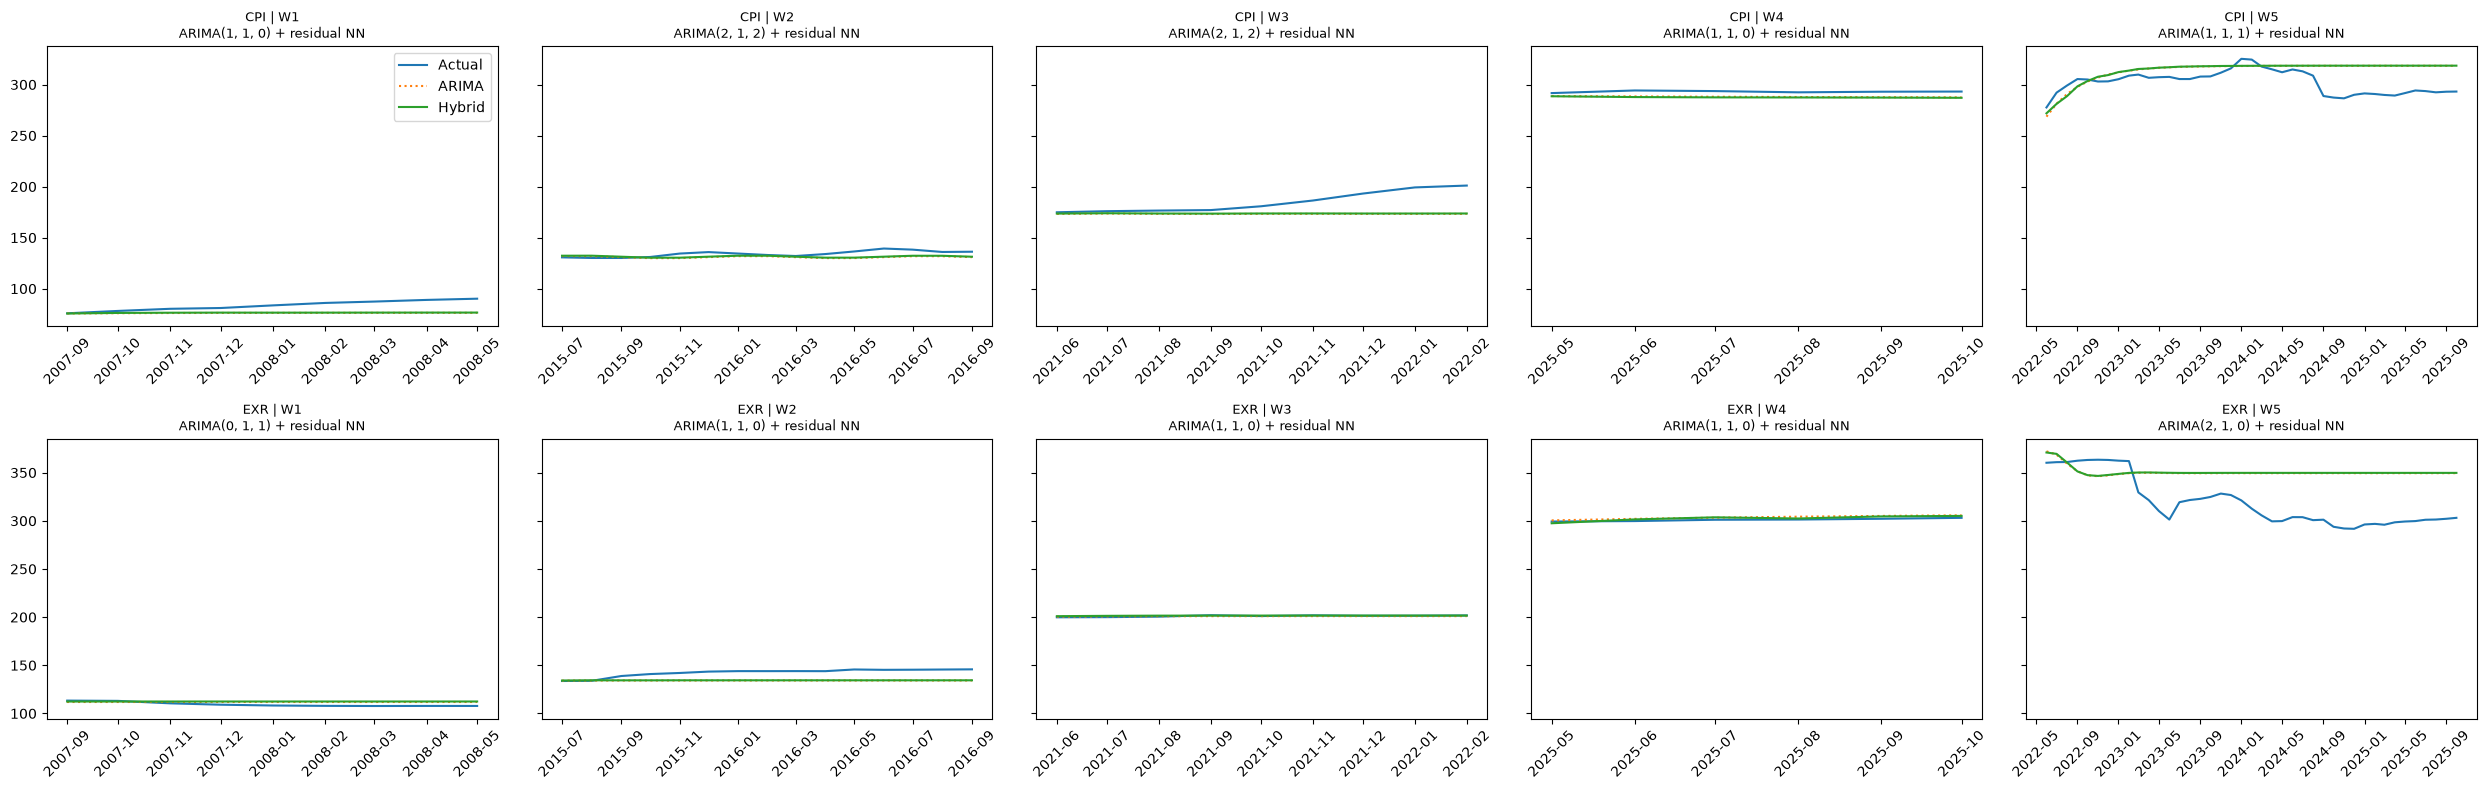

In [8]:
fig, axes = plt.subplots(len(TARGET_COLS), len(WINDOWS), figsize=(5 * len(WINDOWS), 4 * len(TARGET_COLS)), sharey="row")
for col_idx, target in enumerate(TARGET_COLS):
    for win_idx, (label, r) in enumerate(results.items()):
        res = r[target]
        ax = axes[col_idx, win_idx]
        ax.plot(res["test_index"], res["actual"], label="Actual")
        ax.plot(res["test_index"], res["linear_forecast"], label="ARIMA", linestyle=":")
        ax.plot(res["test_index"], res["hybrid_forecast"], label="Hybrid")
        ax.set_title(f"{target} | {label}\nARIMA{res['order']} + residual NN", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [9]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
export_rows = [
    {"window": label, "target": col, "RMSE": r[col]["RMSE"], "MAE": r[col]["MAE"]}
    for label, r in results.items() for col in TARGET_COLS
]
pd.DataFrame(export_rows).to_csv("../results/metrics_hybrid_residual.csv", index=False)

# Raw test-set predictions, in case a later notebook wants to inspect this hybrid's
# forecasts directly rather than just its aggregate error.
pred_rows = [
    {"window": label, "target": col, "date": date, "actual": actual, "predicted": predicted}
    for label, r in results.items() for col in TARGET_COLS
    for date, actual, predicted in zip(r[col]["test_index"], r[col]["actual"], r[col]["hybrid_forecast"])
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_hybrid_residual.csv", index=False)